tensor(0.0036) tensor(1.)
Heatmap saved to regularized_output/self_sim_matrix_heatmap.png


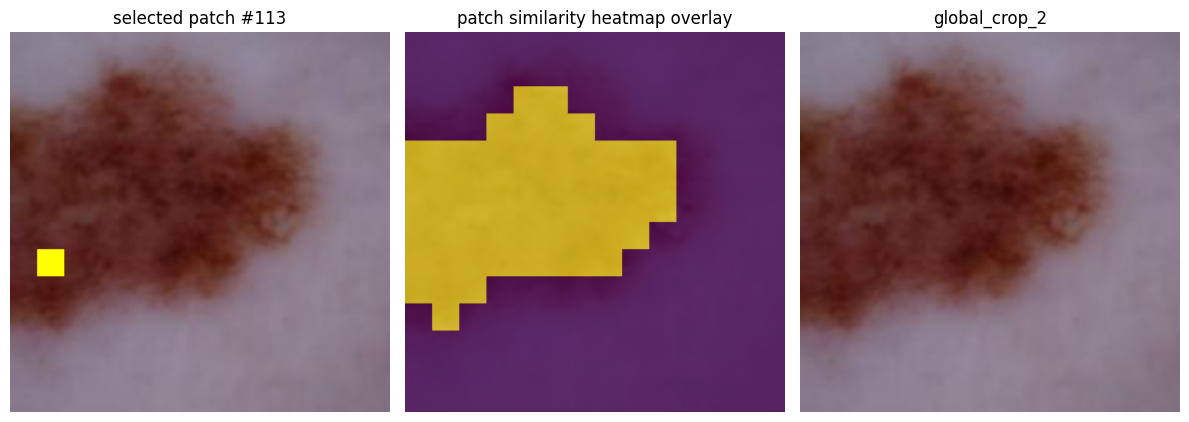

In [2]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import os

# ===== 参数设置 =====
img1_path = "regularized_output/global_2.jpg"
img2_path = "regularized_output/global_2.jpg"
patch_size = 16
output_dir = "regularized_output"

# ===== 加载图片并转Tensor =====
to_tensor = transforms.ToTensor()
to_pil = transforms.ToPILImage()

img1 = Image.open(img1_path).convert("RGB")
a = np.array(img1)
img2 = Image.open(img2_path).convert("RGB")
img1_t = to_tensor(img1)  # [1,3,224,224]
img2_t = to_tensor(img2)

# ===== 切分成16×16 patch =====
def img_to_patches(x, patch_size=16):
    C, H, W = x.shape
    x = x.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size) # [C, num_patches_h, num_patches_w, h, w]
    x = x.contiguous().view(C, -1, patch_size, patch_size)  # [C,num_patches,h,w]
    return x

patches1 = img_to_patches(img1_t, patch_size)
patches2 = img_to_patches(img2_t, patch_size)

C, N, H, W = patches1.shape
num_patches_side = int(224 / patch_size)

# ===== 计算patch特征并余弦相似度 =====
patches1_flat = patches1.permute(1,0,2,3).reshape(N, -1)
patches2_flat = patches2.permute(1,0,2,3).reshape(N, -1)
# patches1_flat = F.normalize(patches1_flat, dim=1) # l2 norm
# patches2_flat = F.normalize(patches2_flat, dim=1)
# 欧氏距离矩阵
dist_matrix = torch.cdist(patches1_flat, patches2_flat, p=2)

# 距离转为“相似度”（越小越相似）
# sim_matrix = torch.exp(- (dist_matrix ** 2) / (2 * (1 ** 2)))
sim_matrix = torch.exp(-0.5*dist_matrix)
sim_bin = (sim_matrix > 0.3).float()
print(sim_matrix.min(), sim_matrix.max())
# 绘制热图
sim_matrix_np = sim_matrix.detach().cpu().numpy()
plt.figure(figsize=(8, 6))  # 可以调整输出图像的大小
plt.imshow(sim_matrix_np, cmap='RdYlBu', interpolation='nearest')  # 使用 viridis 色图
plt.colorbar(label='Similarity')  # 添加色条
plt.title("Patch Similarity Heatmap")  # 图标题
plt.tight_layout()

# 保存热图为 PNG
output_path = f"{output_dir}/self_sim_matrix_heatmap.png"
plt.savefig(output_path, dpi=300)
plt.close()

print(f"Heatmap saved to {output_path}")
# ===== 选取第一个图的某个patch（例如第60个）=====
selected_idx = 113
sim = sim_bin[selected_idx].reshape(num_patches_side, num_patches_side)

# ===== 把选中的patch在原图上染成黄色 =====
img1_np = np.array(img1).astype(np.float32) / 255.0
row = selected_idx // num_patches_side
col = selected_idx % num_patches_side
r0, r1 = row * patch_size, (row + 1) * patch_size
c0, c1 = col * patch_size, (col + 1) * patch_size
# 直接将patch染黄
img1_np[r0:r1, c0:c1, :] = [1.0, 1.0, 0.0]

img1_yellow = Image.fromarray((img1_np * 255).astype(np.uint8))

# ===== 在第二张图上叠加相似度热图 =====
if sim.min() == sim.max():
    sim_norm = torch.zeros_like(sim)
else:
    sim_norm = (sim - sim.min()) / (sim.max() - sim.min())
sim_np = sim_norm.numpy().flatten()
sim_expanded = np.zeros((224, 224))
for i in range(num_patches_side**2):
    row_ = i // num_patches_side
    col_ = i % num_patches_side
    r0_, r1_ = row_ * patch_size, (row_ + 1) * patch_size
    c0_, c1_ = col_ * patch_size, (col_ + 1) * patch_size
    sim_expanded[r0_:r1_, c0_:c1_] = sim_np[i]
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# 左图：染色后的图1
axes[0].imshow(img1_yellow)
axes[0].set_title(f"selected patch #{selected_idx}")
axes[0].axis("off")

# 右图：图2叠加热图
axes[1].imshow(img2)
axes[1].imshow(sim_expanded, cmap='viridis', alpha=0.7)
axes[1].set_title("patch similarity heatmap overlay")
axes[1].axis("off")

axes[2].imshow(img2)
axes[2].set_title("global_crop_2")
axes[2].axis("off")

plt.tight_layout()
plt.show()



In [ ]:
import torch
